In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt

# Allow importing the package from the repo root
sys.path.insert(0, str(Path(".").resolve().parent))

from qaoa_parameter_setting.utils.database.results_database import ResultsDatabase

import figure_styles

[juliapkg] Found dependencies: /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/lib/python3.10/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/lib/python3.10/site-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] Using Julia 1.12.6 at /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env/pyjuliapkg/install/bin/julia
[juliapkg] Finding libjulia:
           | using Libdl
           | print(abspath(Libdl.dlpath("libjulia")))
[juliapkg] Using Julia project at /Users/jju/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | 
           | [compat]
          

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env/Project.toml`
  [6099a3de] + PythonCall v0.9.35
  [458c3c95] ~ OpenSSL_jll ⇒ v3.5.4+0
    Updating `~/.pyenv/versions/3.10.20/envs/qaoa_training_pipeline/julia_env/Manifest.toml`
  [992eb4ea] + CondaPkg v0.2.36
  [9a962f9c] + DataAPI v1.16.0
  [e2d170a0] + DataValueInterfaces v1.0.0
  [82899510] + IteratorInterfaceExtensions v1.0.0
  [692b3bcd] + JLLWrappers v1.8.0
  [682c06a0] + JSON v1.6.1
  [1914dd2f] + MacroTools v0.5.16
  [0b3b1443] + MicroMamba v0.1.15
  [bac558e1] + OrderedCollections v2.0.1
  [69de0a69] + Parsers v2.8.6
  [fa939f87] + Pidfile v1.3.0
  [aea7be01] + PrecompileTools v1.3.4
  [21216c6a] + Preferences v1.5.2
  [6099a3de] + PythonCall v0.9.35
  [6c6a2e73] + Scratch v1.3.0
  [ec057cc2] + StructUtils v2.8.2
  [3783bdb8] + TableTraits v1.0.1
  [bd369af6] + Tables v1.13.0
  [e17b2a0c] + UnsafePointers v

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [ ]:
# ── constants ────────────────────────────────────────────────────────────────
NUM_FILES  = 10           # expected distinct graph instances per (method, depth)
DATA_DIR   = "../data/training/random_regular"
OUTPUT_FILE = "figure_6.pdf"

DEPTHS = [2, 4, 6, 8]    # depths shown in the figure

# pp_max_weight used for each problem class, matching the original figure.
PP_MAX_WEIGHT = {"MIS": 5, "MC": 4}

METHOD_LEGEND_TITLE = "Parameter setting method"

# Canonical method_label strings as produced by ResultsDatabase.
# Order determines the legend and plot-line order.
PP_METHOD_LABELS = [
    "TQA*",
    "Fixed Angles*",
    "Interp.*",
    "Fourier*",
]

In [ ]:
# ── Load data via ResultsDatabase ────────────────────────────────────────────
#
# PP data lessons (mirroring figure_17 MPS lessons):
#
# 1. Filter pp_max_weight FIRST, then dedup — multiple pp_max_weight values
#    exist per (instance, method, depth); deduplicating first would pick
#    whichever weight gives the highest energy, then the weight filter would
#    silently drop instances.
#
# 2. For Fourier/Interp the same depth-N file covers depths 2–N.  Sort by
#    trailing source-file depth number descending so the depth-10 result
#    is preferred over depth-5 etc., replicating the old filename-based
#    selection.
#
# 3. Each TQA/FA per-depth file also produces a noOpt derived variant.
#    Break ties within the same source file by energy descending so the
#    optimised row always wins.


warnings.simplefilter("ignore")

db_mis = ResultsDatabase(problem_class="MIS", num_nodes=[40])
db_mis.add_data(DATA_DIR)

db_mc = ResultsDatabase(problem_class="MC", num_nodes=[40])
db_mc.add_data(DATA_DIR)


def _best_df_pp(db, problem_class, graph_type_filter):
    """One best PP result per (instance, method_label, depth) at the correct weight.

    Filters to the figure's pp_max_weight FIRST, then deduplicates using
    (trailing source-file depth desc, run_datetime desc, energy desc) so
    that depth-10 multi-depth files are preferred and the optimised row
    beats the noOpt derived variant within the same file.
    """
    weight = PP_MAX_WEIGHT[problem_class]
    df = db.to_dataframe().pipe(lambda d: d[
        (d["evaluation"] == "PP")
        & d["instance"].str.contains(graph_type_filter)
        & (d["pp_max_weight"] == weight)
    ]).copy()
    df["_src_depth"] = (
        df["source_file"]
        .str.extract(r'_(\d+)\.json$', expand=False)
        .astype(int)
    )
    df = (
        df
        .sort_values(
            ["_src_depth", "run_datetime", "energy"],
            ascending=[False, False, False],
        )
        .drop_duplicates(subset=["instance", "method_label", "depth"])
        .drop(columns=["_src_depth"])
    )
    return df


df_mis = _best_df_pp(db_mis, "MIS", "random3regular")
df_mc  = _best_df_pp(db_mc,  "MC",  "random3regular")

print(f"Rows loaded — PP: MIS={len(df_mis)}, MC={len(df_mc)}")

/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_68958/349426298.py:38: UserWarning: Missing min-max cut data for instance '008_40nodes_random3regular.json'. Approximation ratio will be NaN.
  df = db.to_dataframe().pipe(lambda d: d[
/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_68958/349426298.py:38: UserWarning: Missing min-max cut data for instance '002_40nodes_random3regular.json'. Approximation ratio will be NaN.
  df = db.to_dataframe().pipe(lambda d: d[
/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_68958/349426298.py:38: UserWarning: Missing min-max cut data for instance '000_40nodes_random3regular.json'. Approximation ratio will be NaN.
  df = db.to_dataframe().pipe(lambda d: d[
/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_68958/349426298.py:38: UserWarning: Missing min-max cut data for instance '003_40nodes_random3regular.json'. Approximation ratio will be NaN.
  df = db.to_dataframe().pipe(lambda d: d[
/var/folders/8w/cdjv1kn9

Rows loaded — PP: MIS=310, MC=380


In [4]:
# ── Coverage report ──────────────────────────────────────────────────────────

def report_coverage(label, df, method_labels, depths):
    print(f"[{label}]")
    sub = df[df["method_label"].isin(method_labels) & df["depth"].isin(depths)]
    stats = (
        sub.groupby(["method_label", "depth"])["instance"]
        .count()
        .reset_index(name="n")
    )
    for _, row in stats.iterrows():
        flag = " *** BELOW TARGET ***" if row["n"] < NUM_FILES else ""
        print(
            f"  method={row['method_label']!r:20s}  depth={row['depth']:2d}  "
            f"n={row['n']}/{NUM_FILES}{flag}"
        )


report_coverage("MIS PP (axs[0])", df_mis, PP_METHOD_LABELS, DEPTHS)
print()
report_coverage("MC  PP (axs[1])", df_mc,  PP_METHOD_LABELS, DEPTHS)

[MIS PP (axs[0])]
  method='Fixed Angles*'       depth= 2  n=10/10
  method='Fixed Angles*'       depth= 4  n=10/10
  method='Fixed Angles*'       depth= 6  n=10/10
  method='Fixed Angles*'       depth= 8  n=10/10
  method='Fourier*'            depth= 2  n=10/10
  method='Fourier*'            depth= 4  n=10/10
  method='Fourier*'            depth= 6  n=10/10
  method='Fourier*'            depth= 8  n=10/10
  method='Interp.*'            depth= 2  n=10/10
  method='Interp.*'            depth= 4  n=10/10
  method='Interp.*'            depth= 6  n=10/10
  method='Interp.*'            depth= 8  n=10/10
  method='TQA*'                depth= 2  n=10/10
  method='TQA*'                depth= 4  n=10/10
  method='TQA*'                depth= 6  n=10/10
  method='TQA*'                depth= 8  n=10/10

[MC  PP (axs[1])]
  method='Fixed Angles*'       depth= 2  n=10/10
  method='Fixed Angles*'       depth= 4  n=10/10
  method='Fixed Angles*'       depth= 6  n=10/10
  method='Fixed Angles*'       d

/var/folders/8w/cdjv1kn93jbgnswgyw7zk05w0000gn/T/ipykernel_68958/1576295681.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


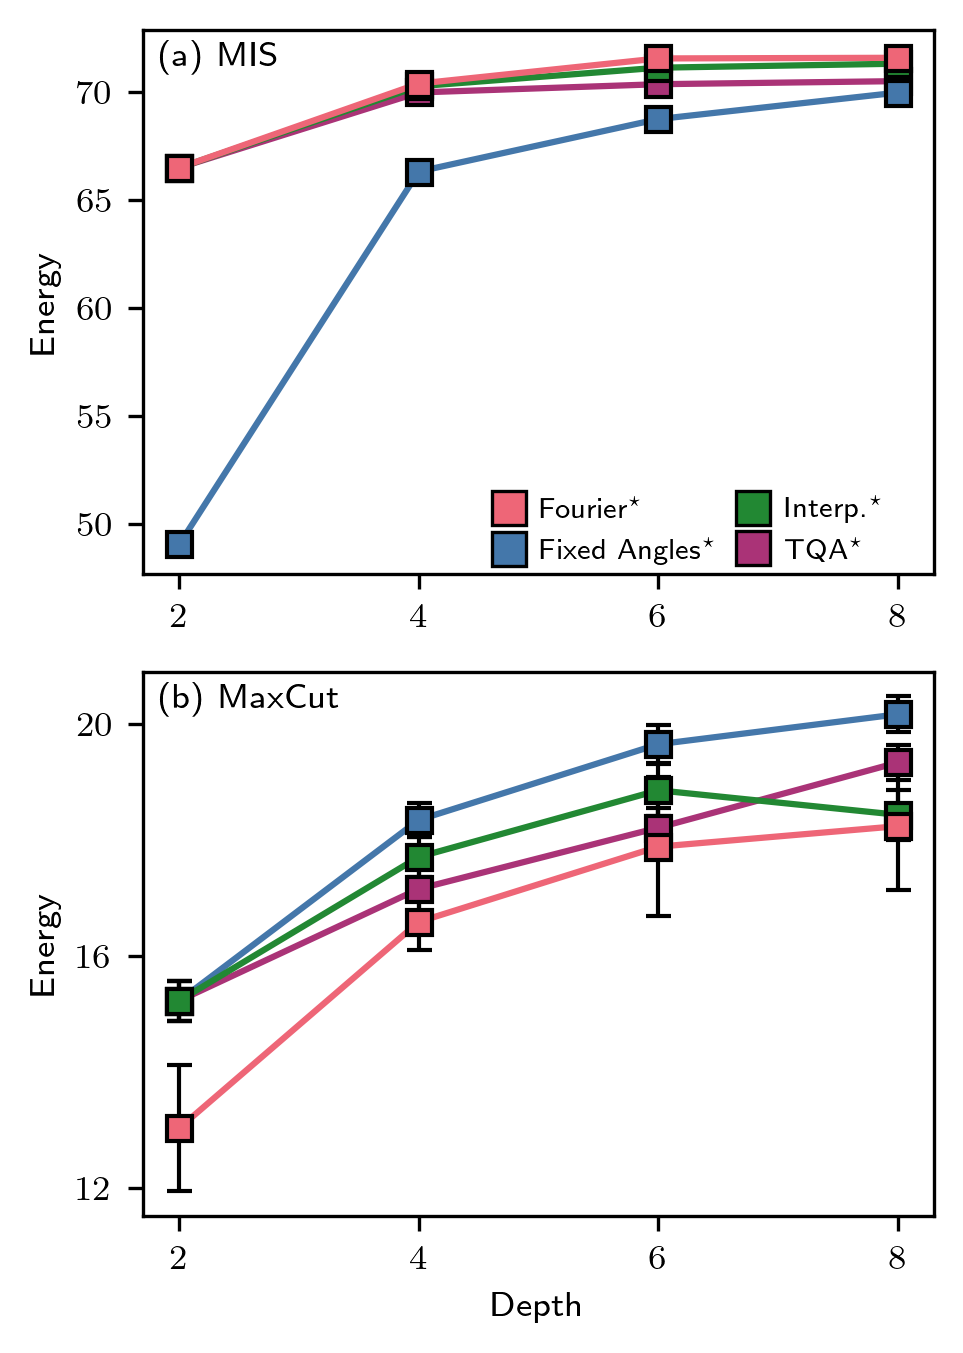

In [11]:
# ── Plot ─────────────────────────────────────────────────────────────────────

figure_styles.apply_rcparams()
fig, axs = plt.subplots(
    2,
    1,
    dpi=figure_styles.FIGURE_DPI,
    figsize=figure_styles.figsize(aspect_ratio=0.8),
)

for ax, df in zip(axs, [df_mis, df_mc]):
    sub = df[df["method_label"].isin(PP_METHOD_LABELS) & df["depth"].isin(DEPTHS)]
    for method_label in PP_METHOD_LABELS:
        rows = sub[sub["method_label"] == method_label]
        if rows.empty:
            continue
        stats = (
            rows.groupby("depth")["energy"]
            .agg(mean="mean", std="std")
            .reset_index()
            .sort_values("depth")
        )
        ax.errorbar(
            stats["depth"].to_numpy(),
            stats["mean"].to_numpy(),
            yerr=stats["std"].to_numpy(),
            label=figure_styles.format_method_label(method_label),
            **figure_styles.style_errorbar(method_label, "PP"),
        )
    ax.set_xticks(DEPTHS)

axs[1].set_xlabel("Depth")
axs[0].set_ylabel("Energy")
axs[1].set_ylabel("Energy")
axs[1].set_yticks([12, 16, 20])

# ── legend ───────────────────────────────────────────────────────────────────

method_legend_items = [
    ("Fourier",       "Fourier"),
    ("Fixed Angles*", "Fixed Angles*"),
    ("INTERP",        "INTERP"),
    ("TQA*",          "TQA*"),
]
method_handles = [
    figure_styles.method_legend_handle(
        figure_styles.format_method_label(label), method
    )
    for label, method in method_legend_items
]
axs[0].legend(handles=method_handles, **figure_styles.method_legend_kwargs())

figure_styles.add_panel_labels(axs, labels=("(a) MIS", "(b) MaxCut"))
figure_styles.adjust_subplots_for_legend(fig, bottom=-0.05, wspace=0)

fig.savefig(OUTPUT_FILE, **figure_styles.savefig_kwargs())
fig.show()